In [409]:
!pip install -q rdkit chembl_webresource_client xgboost

In [410]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen, Lipinski, AllChem

from chembl_webresource_client.new_client import new_client

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

print("Setup complete")

Setup complete


In [411]:
activity = new_client.activity

records = activity.filter(
    target_chembl_id="CHEMBL203",
    standard_type="IC50"
).only([
    "molecule_chembl_id",
    "canonical_smiles",
    "standard_value",
    "standard_units",
    "standard_relation",
    "assay_chembl_id"
])

test_records = list(records[:100])

df_test = pd.DataFrame(test_records)

print("Test dataset shape:", df_test.shape)

df_test.head()

Test dataset shape: (100, 9)


,assay_chembl_id,canonical_smiles,molecule_chembl_id,relation,standard_relation,standard_units,standard_value,units,value
0,CHEMBL674637,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,CHEMBL68920,=,=,nM,41.0,uM,0.041
1,CHEMBL621151,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,CHEMBL68920,=,=,nM,300.0,uM,0.3
2,CHEMBL615325,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,CHEMBL68920,=,=,nM,7820.0,uM,7.82
3,CHEMBL674637,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,CHEMBL69960,=,=,nM,170.0,uM,0.17
4,CHEMBL621151,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,CHEMBL69960,=,=,nM,40.0,uM,0.04


In [414]:
all_records = []
batch_size = 500
start = 0

while True:
    print(f"Downloading records {start} to {start + batch_size}...")

    batch = list(records[start:start + batch_size])

    if len(batch) == 0:
        break

    all_records.extend(batch)

    if len(batch) < batch_size:
        break

    start += batch_size

print("Total records downloaded:", len(all_records))

Total records downloaded: 520


In [415]:
df = pd.DataFrame(all_records)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (520, 9)


,assay_chembl_id,canonical_smiles,molecule_chembl_id,relation,standard_relation,standard_units,standard_value,units,value
0,CHEMBL674637,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,CHEMBL68920,=,=,nM,41.0,uM,0.041
1,CHEMBL621151,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,CHEMBL68920,=,=,nM,300.0,uM,0.3
2,CHEMBL615325,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,CHEMBL68920,=,=,nM,7820.0,uM,7.82
3,CHEMBL674637,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,CHEMBL69960,=,=,nM,170.0,uM,0.17
4,CHEMBL621151,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,CHEMBL69960,=,=,nM,40.0,uM,0.04


In [416]:
activity = new_client.activity

records = activity.filter(
    target_chembl_id="CHEMBL203",
    standard_type="IC50",
    standard_units="nM",
    standard_relation="="
).only([
    "molecule_chembl_id",
    "canonical_smiles",
    "standard_value",
    "standard_units",
    "standard_relation",
    "assay_chembl_id"
])

In [417]:
print("Shape:", df.shape)
df.head()

Shape: (520, 9)


,assay_chembl_id,canonical_smiles,molecule_chembl_id,relation,standard_relation,standard_units,standard_value,units,value
0,CHEMBL674637,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,CHEMBL68920,=,=,nM,41.0,uM,0.041
1,CHEMBL621151,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,CHEMBL68920,=,=,nM,300.0,uM,0.3
2,CHEMBL615325,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,CHEMBL68920,=,=,nM,7820.0,uM,7.82
3,CHEMBL674637,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,CHEMBL69960,=,=,nM,170.0,uM,0.17
4,CHEMBL621151,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,CHEMBL69960,=,=,nM,40.0,uM,0.04


In [418]:
df.isna().sum()

,0
assay_chembl_id,0
canonical_smiles,0
molecule_chembl_id,0
relation,0
standard_relation,0
standard_units,0
standard_value,0
units,29
value,0


In [419]:
clean = df.copy()

clean = clean.dropna(
    subset=[
        "canonical_smiles",
        "standard_value",
        "standard_units",
        "standard_relation"
    ]
)

clean["standard_value"] = pd.to_numeric(
    clean["standard_value"],
    errors="coerce"
)

clean = clean.dropna(subset=["standard_value"])

clean = clean[clean["standard_value"] > 0]

print("Cleaned shape:", clean.shape)

Cleaned shape: (520, 9)


In [420]:
def canonicalize_smiles(smiles):
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None

    return Chem.MolToSmiles(mol, canonical=True)

In [421]:
clean["canonical_smiles_std"] = clean[
    "canonical_smiles"
].apply(canonicalize_smiles)

clean = clean.dropna(
    subset=["canonical_smiles_std"]
)

print(clean.shape)

(520, 10)


In [422]:
compound_df = (
    clean.groupby(
        "canonical_smiles_std",
        as_index=False
    )
    .agg(
        IC50_nM=("standard_value", "median"),
        n_records=("standard_value", "size")
    )
)

print("Unique compounds:", compound_df.shape[0])

compound_df.head()

Unique compounds: 387


,canonical_smiles_std,IC50_nM,n_records
0,Brc1cccc(Nc2ccnc3ccccc23)c1,5500.00,1
1,Brc1cccc(Nc2ncnc3cc4[nH]cc(CN5CCOCC5)c4cc23)c1,7.20,2
2,Brc1cccc(Nc2ncnc3cc4[nH]ccc4cc23)c1,0.44,3
3,Brc1cccc(Nc2ncnc3cc4[nH]ncc4cc23)c1,0.44,3
4,Brc1cccc(Nc2ncnc3cc4c(ccn4CCN4CCOCC4)cc23)c1,9.85,2


In [423]:
compound_df["pIC50"] = (
    9 - np.log10(compound_df["IC50_nM"])
)

compound_df[
    ["IC50_nM", "pIC50"]
].head()

,IC50_nM,pIC50
0,5500.00,5.259637
1,7.20,8.142668
2,0.44,9.356547
3,0.44,9.356547
4,9.85,8.006564


In [424]:
def activity_label(pIC50):
    if pIC50 >= 6.0:
        return 1
    if pIC50 <= 5.0:
        return 0
    return np.nan

In [425]:
compound_df["Activity"] = compound_df[
    "pIC50"
].apply(activity_label)

model_df = compound_df.dropna(
    subset=["Activity"]
).copy()

model_df["Activity"] = model_df[
    "Activity"
].astype(int)

print(model_df["Activity"].value_counts())

Activity
1    215
0     93
Name: count, dtype: int64


In [426]:
print(clean.shape)
print(compound_df.shape)
print(model_df.shape)
print(model_df["Activity"].value_counts())

(520, 10)
(387, 5)
(308, 5)
Activity
1    215
0     93
Name: count, dtype: int64


In [427]:
def calc_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)

    return pd.Series({
        "MolWt": Descriptors.MolWt(mol),
        "LogP": Crippen.MolLogP(mol),
        "HBD": Lipinski.NumHDonors(mol),
        "HBA": Lipinski.NumHAcceptors(mol),
        "TPSA": Descriptors.TPSA(mol),
        "RotBonds": Lipinski.NumRotatableBonds(mol)
    })

In [428]:
descriptor_df = model_df[
    "canonical_smiles_std"
].apply(calc_descriptors)

descriptor_df.head()

,MolWt,LogP,HBD,HBA,TPSA,RotBonds
1,438.329,4.4494,2.0,5.0,66.07,4.0
2,339.196,4.6172,2.0,3.0,53.60,2.0
3,340.184,4.0122,2.0,4.0,66.49,2.0
4,452.356,4.4228,1.0,5.0,55.21,5.0
5,467.371,4.2079,1.0,6.0,68.10,6.0


In [429]:
model_desc = pd.concat(
    [
        model_df.reset_index(drop=True),
        descriptor_df.reset_index(drop=True)
    ],
    axis=1
)

model_desc.head()

,canonical_smiles_std,IC50_nM,n_records,pIC50,Activity,MolWt,LogP,HBD,HBA,TPSA,RotBonds
0,Brc1cccc(Nc2ncnc3cc4[nH]cc(CN5CCOCC5)c4cc23)c1,7.20,2,8.142668,1,438.329,4.4494,2.0,5.0,66.07,4.0
1,Brc1cccc(Nc2ncnc3cc4[nH]ccc4cc23)c1,0.44,3,9.356547,1,339.196,4.6172,2.0,3.0,53.60,2.0
2,Brc1cccc(Nc2ncnc3cc4[nH]ncc4cc23)c1,0.44,3,9.356547,1,340.184,4.0122,2.0,4.0,66.49,2.0
3,Brc1cccc(Nc2ncnc3cc4c(ccn4CCN4CCOCC4)cc23)c1,9.85,2,8.006564,1,452.356,4.4228,1.0,5.0,55.21,5.0
4,Brc1cccc(Nc2ncnc3cc4c(cnn4CCCN4CCOCC4)cc23)c1,42.90,2,7.367543,1,467.371,4.2079,1.0,6.0,68.10,6.0


In [430]:
descriptor_cols = [
    "MolWt",
    "LogP",
    "HBD",
    "HBA",
    "TPSA",
    "RotBonds"
]

model_desc[descriptor_cols].describe()

,MolWt,LogP,HBD,HBA,TPSA,RotBonds
count,308.000000,308.000000,308.00000,308.000000,308.000000,308.000000
mean,386.059763,3.710220,2.00000,5.227273,85.279416,4.912338
std,122.416503,1.559255,1.00811,1.450700,22.917678,2.890303
min,143.149000,-1.303840,0.00000,2.000000,32.340000,0.000000
25%,291.834500,2.594025,1.00000,4.000000,66.910000,3.000000
50%,397.838000,3.828960,2.00000,5.000000,83.340000,4.000000
75%,475.608250,4.650925,3.00000,6.000000,101.772500,7.000000
max,742.644000,9.499000,6.00000,9.000000,160.760000,14.000000


In [431]:
def morgan_fp(smiles, radius=2, n_bits=2048):
    mol = Chem.MolFromSmiles(smiles)

    fp = AllChem.GetMorganFingerprintAsBitVect(
        mol,
        radius,
        nBits=n_bits
    )

    return np.array(fp, dtype=int)

In [432]:
X_fp = np.vstack(
    model_df[
        "canonical_smiles_std"
    ].apply(morgan_fp).values
)

y = model_df["Activity"].values

print("X shape:", X_fp.shape)
print("y shape:", y.shape)

[06:53:39] DEPRECATION WARNING: please use MorganGenerator
[06:53:39] DEPRECATION WARNING: please use MorganGenerator
[06:53:39] DEPRECATION WARNING: please use MorganGenerator
[06:53:39] DEPRECATION WARNING: please use MorganGenerator
[06:53:39] DEPRECATION WARNING: please use MorganGenerator
[06:53:39] DEPRECATION WARNING: please use MorganGenerator
[06:53:39] DEPRECATION WARNING: please use MorganGenerator
[06:53:39] DEPRECATION WARNING: please use MorganGenerator
[06:53:39] DEPRECATION WARNING: please use MorganGenerator
[06:53:39] DEPRECATION WARNING: please use MorganGenerator
[06:53:39] DEPRECATION WARNING: please use MorganGenerator
[06:53:39] DEPRECATION WARNING: please use MorganGenerator
[06:53:39] DEPRECATION WARNING: please use MorganGenerator
[06:53:39] DEPRECATION WARNING: please use MorganGenerator
[06:53:39] DEPRECATION WARNING: please use MorganGenerator
[06:53:39] DEPRECATION WARNING: please use MorganGenerator
[06:53:39] DEPRECATION WARNING: please use MorganGenerat

X shape: (308, 2048)
y shape: (308,)


[06:53:40] DEPRECATION WARNING: please use MorganGenerator
[06:53:40] DEPRECATION WARNING: please use MorganGenerator
[06:53:40] DEPRECATION WARNING: please use MorganGenerator
[06:53:40] DEPRECATION WARNING: please use MorganGenerator
[06:53:40] DEPRECATION WARNING: please use MorganGenerator
[06:53:40] DEPRECATION WARNING: please use MorganGenerator
[06:53:40] DEPRECATION WARNING: please use MorganGenerator
[06:53:40] DEPRECATION WARNING: please use MorganGenerator
[06:53:40] DEPRECATION WARNING: please use MorganGenerator
[06:53:40] DEPRECATION WARNING: please use MorganGenerator
[06:53:40] DEPRECATION WARNING: please use MorganGenerator
[06:53:40] DEPRECATION WARNING: please use MorganGenerator
[06:53:40] DEPRECATION WARNING: please use MorganGenerator
[06:53:40] DEPRECATION WARNING: please use MorganGenerator
[06:53:40] DEPRECATION WARNING: please use MorganGenerator
[06:53:40] DEPRECATION WARNING: please use MorganGenerator
[06:53:40] DEPRECATION WARNING: please use MorganGenerat

In [433]:
X_train, X_test, y_train, y_test = train_test_split(
    X_fp,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (246, 2048)
Test set: (62, 2048)


In [434]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

log_model.fit(X_train, y_train)

print("Logistic Regression trained")

Logistic Regression trained


In [435]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=500,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest trained")

Random Forest trained


In [436]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

spw = neg / pos

print("Inactive:", neg)
print("Active:", pos)
print("Scale pos weight:", spw)

Inactive: 74
Active: 172
Scale pos weight: 0.43023255813953487


In [437]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=spw,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

print("XGBoost trained")

XGBoost trained


In [438]:
def evaluate(name, model, X, y):
    pred = model.predict(X)
    prob = model.predict_proba(X)[:, 1]

    return {
        "Model": name,
        "Accuracy": accuracy_score(y, pred),
        "Precision": precision_score(y, pred, zero_division=0),
        "Recall": recall_score(y, pred, zero_division=0),
        "F1": f1_score(y, pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y, prob),
        "PR_AUC": average_precision_score(y, prob)
    }

In [439]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

log_model.fit(X_train, y_train)

print("Logistic Regression trained successfully")

Logistic Regression trained successfully


In [440]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=500,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest trained successfully")

Random Forest trained successfully


In [441]:
from xgboost import XGBClassifier

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

spw = neg / pos

xgb_model = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=spw,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

print("XGBoost trained successfully")

XGBoost trained successfully


In [442]:
def evaluate(name, model, X, y):
    pred = model.predict(X)
    prob = model.predict_proba(X)[:, 1]

    return {
        "Model": name,
        "Accuracy": accuracy_score(y, pred),
        "Precision": precision_score(y, pred, zero_division=0),
        "Recall": recall_score(y, pred, zero_division=0),
        "F1": f1_score(y, pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y, prob),
        "PR_AUC": average_precision_score(y, prob)
    }

In [443]:
results = pd.DataFrame([
    evaluate(
        "Logistic Regression",
        log_model,
        X_test,
        y_test
    ),
    evaluate(
        "Random Forest",
        rf_model,
        X_test,
        y_test
    ),
    evaluate(
        "XGBoost",
        xgb_model,
        X_test,
        y_test
    )
])

results.round(3)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.935,0.976,0.930,0.952,0.994,0.997
1,Random Forest,0.935,1.000,0.907,0.951,0.994,0.997
2,XGBoost,0.952,1.000,0.930,0.964,0.996,0.998


In [444]:
log_pred = log_model.predict(X_test)

print("LOGISTIC REGRESSION")
print(
    classification_report(
        y_test,
        log_pred
    )
)

LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       0.86      0.95      0.90        19
           1       0.98      0.93      0.95        43

    accuracy                           0.94        62
   macro avg       0.92      0.94      0.93        62
weighted avg       0.94      0.94      0.94        62



In [445]:
rf_pred = rf_model.predict(X_test)

print("RANDOM FOREST")
print(
    classification_report(
        y_test,
        rf_pred
    )
)

RANDOM FOREST
              precision    recall  f1-score   support

           0       0.83      1.00      0.90        19
           1       1.00      0.91      0.95        43

    accuracy                           0.94        62
   macro avg       0.91      0.95      0.93        62
weighted avg       0.95      0.94      0.94        62



In [446]:
xgb_pred = xgb_model.predict(X_test)

print("XGBOOST")
print(
    classification_report(
        y_test,
        xgb_pred
    )
)

XGBOOST
              precision    recall  f1-score   support

           0       0.86      1.00      0.93        19
           1       1.00      0.93      0.96        43

    accuracy                           0.95        62
   macro avg       0.93      0.97      0.95        62
weighted avg       0.96      0.95      0.95        62



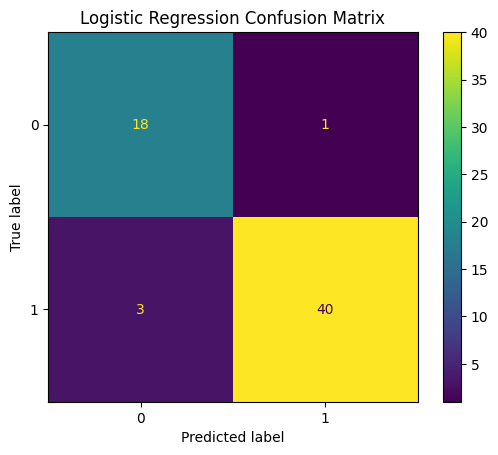

In [447]:
ConfusionMatrixDisplay.from_estimator(
    log_model,
    X_test,
    y_test
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

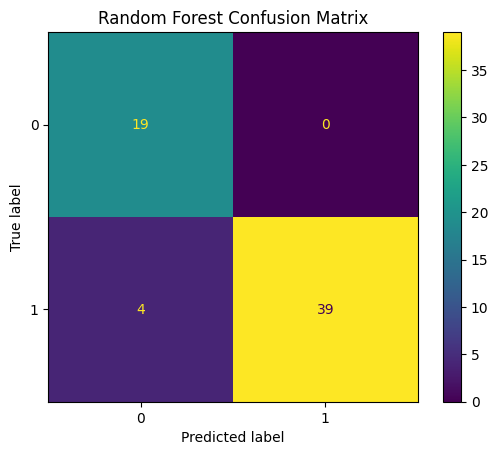

In [448]:
ConfusionMatrixDisplay.from_estimator(
    rf_model,
    X_test,
    y_test
)

plt.title("Random Forest Confusion Matrix")
plt.show()

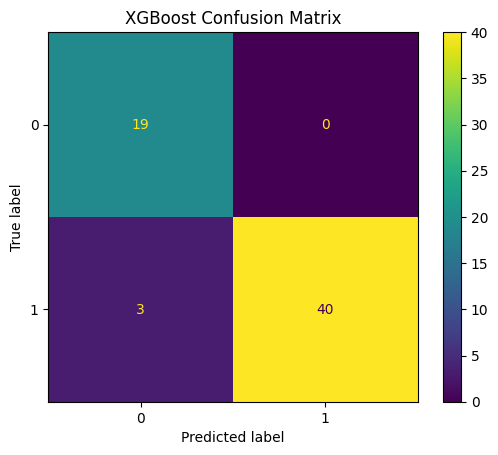

In [449]:
ConfusionMatrixDisplay.from_estimator(
    xgb_model,
    X_test,
    y_test
)

plt.title("XGBoost Confusion Matrix")
plt.show()

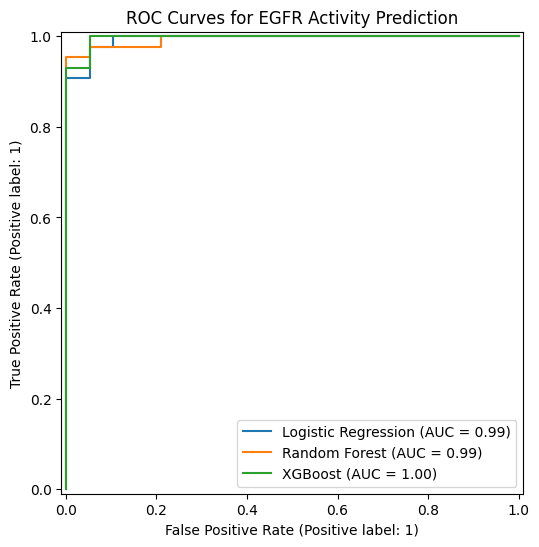

In [450]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, model in [
    ("Logistic Regression", log_model),
    ("Random Forest", rf_model),
    ("XGBoost", xgb_model)
]:
    RocCurveDisplay.from_estimator(
        model,
        X_test,
        y_test,
        ax=ax,
        name=name
    )

plt.title("ROC Curves for EGFR Activity Prediction")
plt.show()

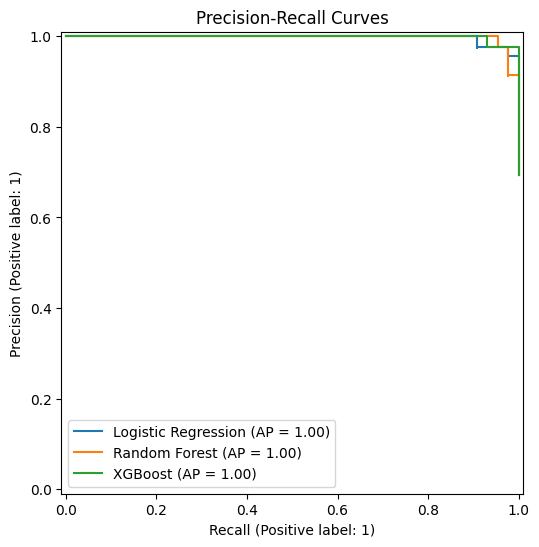

In [451]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, model in [
    ("Logistic Regression", log_model),
    ("Random Forest", rf_model),
    ("XGBoost", xgb_model)
]:
    PrecisionRecallDisplay.from_estimator(
        model,
        X_test,
        y_test,
        ax=ax,
        name=name
    )

plt.title("Precision-Recall Curves")
plt.show()

In [452]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [453]:
descriptor_cols = [
    "MolWt",
    "LogP",
    "HBD",
    "HBA",
    "TPSA",
    "RotBonds"
]

X_desc = model_desc[descriptor_cols]
y_desc = model_desc["Activity"]

In [454]:
Xd_train, Xd_test, yd_train, yd_test = train_test_split(
    X_desc,
    y_desc,
    test_size=0.20,
    random_state=42,
    stratify=y_desc
)

In [455]:
Xd_train, Xd_test, yd_train, yd_test = train_test_split(
    X_desc,
    y_desc,
    test_size=0.20,
    random_state=42,
    stratify=y_desc
)

In [456]:
descriptor_model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        )
    )
])

descriptor_model.fit(
    Xd_train,
    yd_train
)

print("Descriptor model trained")

Descriptor model trained


In [457]:
descriptor_result = evaluate(
    "Descriptor Logistic Regression",
    descriptor_model,
    Xd_test,
    yd_test
)

pd.DataFrame(
    [descriptor_result]
).round(3)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Descriptor Logistic Regression,0.839,0.946,0.814,0.875,0.927,0.956


In [458]:
coefficients = descriptor_model[
    "model"
].coef_[0]

coef_df = pd.DataFrame({
    "Descriptor": descriptor_cols,
    "Coefficient": coefficients
})

coef_df = coef_df.sort_values(
    "Coefficient",
    ascending=False
)

coef_df

,Descriptor,Coefficient
3,HBA,1.437466
0,MolWt,1.430987
5,RotBonds,0.204914
2,HBD,-0.068058
1,LogP,-0.839879
4,TPSA,-1.574641


In [459]:
coefficients = descriptor_model[
    "model"
].coef_[0]

coef_df = pd.DataFrame({
    "Descriptor": descriptor_cols,
    "Coefficient": coefficients
})

coef_df = coef_df.sort_values(
    "Coefficient",
    ascending=False
)

coef_df

,Descriptor,Coefficient
3,HBA,1.437466
0,MolWt,1.430987
5,RotBonds,0.204914
2,HBD,-0.068058
1,LogP,-0.839879
4,TPSA,-1.574641


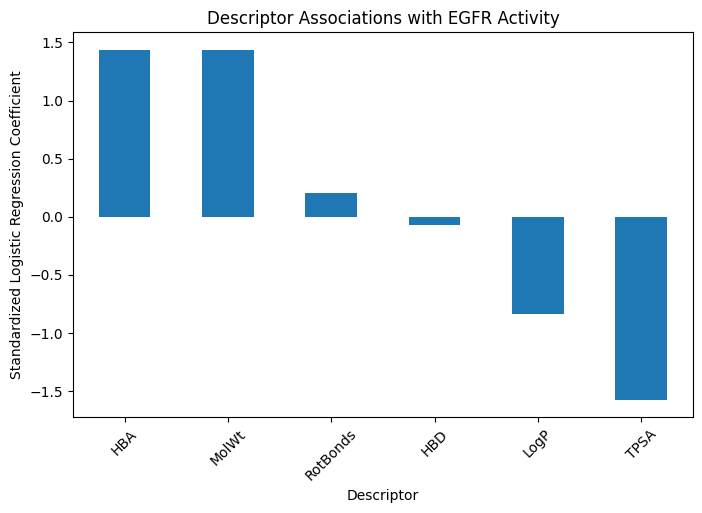

In [460]:
coef_df.plot(
    x="Descriptor",
    y="Coefficient",
    kind="bar",
    legend=False,
    figsize=(8, 5)
)

plt.ylabel(
    "Standardized Logistic Regression Coefficient"
)

plt.title(
    "Descriptor Associations with EGFR Activity"
)

plt.xticks(rotation=45)

plt.show()

In [461]:
model_desc.to_csv(
    "EGFR_curated_bioactivity.csv",
    index=False
)

print("Curated dataset saved")

Curated dataset saved


In [462]:
results.to_csv(
    "model_results.csv",
    index=False
)

print("Model results saved")

Model results saved


In [463]:
coef_df.to_csv(
    "descriptor_coefficients.csv",
    index=False
)

print("Descriptor coefficients saved")

Descriptor coefficients saved


In [464]:
print("Raw ChEMBL records:", len(df))
print("After cleaning:", len(clean))
print("Unique compounds:", len(compound_df))
print("Compounds used for classification:", len(model_df))

print("\nClass counts:")
print(
    model_df[
        "Activity"
    ].value_counts()
)

print("\nModel results:")
display(results.round(3))

Raw ChEMBL records: 520
After cleaning: 520
Unique compounds: 387
Compounds used for classification: 308

Class counts:
Activity
1    215
0     93
Name: count, dtype: int64

Model results:


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.935,0.976,0.930,0.952,0.994,0.997
1,Random Forest,0.935,1.000,0.907,0.951,0.994,0.997
2,XGBoost,0.952,1.000,0.930,0.964,0.996,0.998


In [465]:
from google.colab import files
files.download("EGFR_Final_Candidate_Comparison.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [466]:
model_desc.to_csv(
    "EGFR_curated_bioactivity.csv",
    index=False
)

results.to_csv(
    "model_results.csv",
    index=False
)

coef_df.to_csv(
    "descriptor_coefficients.csv",
    index=False
)

print("Files saved in Colab")

Files saved in Colab


In [467]:
results.round(3)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.935,0.976,0.930,0.952,0.994,0.997
1,Random Forest,0.935,1.000,0.907,0.951,0.994,0.997
2,XGBoost,0.952,1.000,0.930,0.964,0.996,0.998


In [468]:
def safe_morgan_fp(smiles, radius=2, n_bits=2048):
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None

    fp = AllChem.GetMorganFingerprintAsBitVect(
        mol,
        radius,
        nBits=n_bits
    )

    return np.array(fp, dtype=int)

In [469]:
new_smiles = [
    "CCOc1ccc2nc(S(N)(=O)=O)sc2c1",
    "CC(C)(C)c1ccc(cc1)C(=O)O",
    "COc1ccc2nc(NC3CCCCC3)nc2c1"
]

valid_smiles = []
valid_fps = []

for smi in new_smiles:
    fp = safe_morgan_fp(smi)

    if fp is not None:
        valid_smiles.append(smi)
        valid_fps.append(fp)
    else:
        print("Invalid SMILES skipped:", smi)

new_fps = np.vstack(valid_fps)

new_probs = xgb_model.predict_proba(new_fps)[:, 1]
new_preds = xgb_model.predict(new_fps)

prediction_df = pd.DataFrame({
    "SMILES": valid_smiles,
    "Predicted_Activity": new_preds,
    "Probability_Active": new_probs
})

prediction_df

Invalid SMILES skipped: COc1ccc2nc(NC3CCCCC3)nc2c1


[06:53:51] DEPRECATION WARNING: please use MorganGenerator
[06:53:51] DEPRECATION WARNING: please use MorganGenerator
[06:53:51] Can't kekulize mol.  Unkekulized atoms: 2 3 4 5 6 7 15 16 17
[06:53:51] Can't kekulize mol.  Unkekulized atoms: 2 3 4 5 6 7 15 16 17


,SMILES,Predicted_Activity,Probability_Active
0,CCOc1ccc2nc(S(N)(=O)=O)sc2c1,1,0.703837
1,CC(C)(C)c1ccc(cc1)C(=O)O,0,0.003742


In [470]:
def morgan_fp_safe(smiles, radius=2, n_bits=2048):
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None

    fp = AllChem.GetMorganFingerprintAsBitVect(
        mol,
        radius,
        nBits=n_bits
    )

    return np.array(fp, dtype=int)

In [471]:
for smi in new_smiles:
    mol = Chem.MolFromSmiles(smi)
    print(smi, "VALID" if mol is not None else "INVALID")

CCOc1ccc2nc(S(N)(=O)=O)sc2c1 VALID
CC(C)(C)c1ccc(cc1)C(=O)O VALID
COc1ccc2nc(NC3CCCCC3)nc2c1 INVALID


[06:53:51] Can't kekulize mol.  Unkekulized atoms: 2 3 4 5 6 7 15 16 17
[06:53:51] Can't kekulize mol.  Unkekulized atoms: 2 3 4 5 6 7 15 16 17


In [472]:
valid_smiles = []
valid_fps = []

for smi in new_smiles:
    fp = morgan_fp_safe(smi)

    if fp is not None:
        valid_smiles.append(smi)
        valid_fps.append(fp)

print("Valid molecules:", len(valid_smiles))

Valid molecules: 2


[06:53:51] DEPRECATION WARNING: please use MorganGenerator
[06:53:51] DEPRECATION WARNING: please use MorganGenerator
[06:53:51] Can't kekulize mol.  Unkekulized atoms: 2 3 4 5 6 7 15 16 17
[06:53:51] Can't kekulize mol.  Unkekulized atoms: 2 3 4 5 6 7 15 16 17


In [473]:
new_fps = np.vstack(valid_fps)

new_probs = xgb_model.predict_proba(new_fps)[:, 1]
new_preds = xgb_model.predict(new_fps)

prediction_df = pd.DataFrame({
    "SMILES": valid_smiles,
    "Predicted_Activity": new_preds,
    "Probability_Active": new_probs
})

prediction_df

,SMILES,Predicted_Activity,Probability_Active
0,CCOc1ccc2nc(S(N)(=O)=O)sc2c1,1,0.703837
1,CC(C)(C)c1ccc(cc1)C(=O)O,0,0.003742


In [474]:
from google.colab import files

uploaded = files.upload()

Saving external_compounds.csv to external_compounds (2).csv


In [475]:
external_df = pd.read_csv("external_compounds.csv")

external_df.head()

,Name,SMILES
0,Compound_1,CCOc1ccc2nc(S(N)(=O)=O)sc2c1
1,Compound_2,CC(C)(C)c1ccc(cc1)C(=O)O


In [476]:
def valid_smiles(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return mol is not None

external_df["Valid_SMILES"] = external_df["SMILES"].apply(valid_smiles)

print(external_df["Valid_SMILES"].value_counts())

Valid_SMILES
True    2
Name: count, dtype: int64


In [477]:
external_df = external_df[
    external_df["Valid_SMILES"]
].copy()

print("Valid external molecules:", len(external_df))

Valid external molecules: 2


In [478]:
external_df["Canonical_SMILES"] = external_df[
    "SMILES"
].apply(canonicalize_smiles)

external_df.head()

,Name,SMILES,Valid_SMILES,Canonical_SMILES
0,Compound_1,CCOc1ccc2nc(S(N)(=O)=O)sc2c1,True,CCOc1ccc2nc(S(N)(=O)=O)sc2c1
1,Compound_2,CC(C)(C)c1ccc(cc1)C(=O)O,True,CC(C)(C)c1ccc(C(=O)O)cc1


In [479]:
training_smiles = set(
    model_df["canonical_smiles_std"]
)

external_df = external_df[
    ~external_df["Canonical_SMILES"].isin(training_smiles)
].copy()

print(
    "Truly external molecules remaining:",
    len(external_df)
)

Truly external molecules remaining: 2


In [480]:
external_fps = np.vstack(
    external_df[
        "Canonical_SMILES"
    ].apply(morgan_fp).values
)

print(external_fps.shape)

(2, 2048)


[06:59:27] DEPRECATION WARNING: please use MorganGenerator
[06:59:27] DEPRECATION WARNING: please use MorganGenerator


In [481]:
external_df["Predicted_Activity"] = (
    xgb_model.predict(external_fps)
)

external_df["Probability_Active"] = (
    xgb_model.predict_proba(external_fps)[:, 1]
)

external_df.head()

,Name,SMILES,Valid_SMILES,Canonical_SMILES,Predicted_Activity,Probability_Active
0,Compound_1,CCOc1ccc2nc(S(N)(=O)=O)sc2c1,True,CCOc1ccc2nc(S(N)(=O)=O)sc2c1,1,0.703837
1,Compound_2,CC(C)(C)c1ccc(cc1)C(=O)O,True,CC(C)(C)c1ccc(C(=O)O)cc1,0,0.003742


In [482]:
ranked_candidates = external_df.sort_values(
    "Probability_Active",
    ascending=False
).reset_index(drop=True)

ranked_candidates[
    [
        "Name",
        "Canonical_SMILES",
        "Predicted_Activity",
        "Probability_Active"
    ]
].head(20)

,Name,Canonical_SMILES,Predicted_Activity,Probability_Active
0,Compound_1,CCOc1ccc2nc(S(N)(=O)=O)sc2c1,1,0.703837
1,Compound_2,CC(C)(C)c1ccc(C(=O)O)cc1,0,0.003742


In [483]:
ranked_candidates.to_csv(
    "EGFR_external_predictions.csv",
    index=False
)

print("Predictions saved")

Predictions saved


In [484]:
files.download(
    "EGFR_external_predictions.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [485]:
high_priority = ranked_candidates[
    ranked_candidates["Probability_Active"] >= 0.80
].copy()

print(
    "High-priority predicted candidates:",
    len(high_priority)
)

high_priority.head(10)

High-priority predicted candidates: 0


,Name,SMILES,Valid_SMILES,Canonical_SMILES,Predicted_Activity,Probability_Active


In [486]:
from rdkit.Chem.Scaffolds import MurckoScaffold

def get_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    return MurckoScaffold.MurckoScaffoldSmiles(
        mol=mol,
        includeChirality=False
    )

model_df["Scaffold"] = model_df[
    "canonical_smiles_std"
].apply(get_scaffold)

model_df[["canonical_smiles_std", "Scaffold"]].head()

,canonical_smiles_std,Scaffold
1,Brc1cccc(Nc2ncnc3cc4[nH]cc(CN5CCOCC5)c4cc23)c1,c1ccc(Nc2ncnc3cc4[nH]cc(CN5CCOCC5)c4cc23)cc1
2,Brc1cccc(Nc2ncnc3cc4[nH]ccc4cc23)c1,c1ccc(Nc2ncnc3cc4[nH]ccc4cc23)cc1
3,Brc1cccc(Nc2ncnc3cc4[nH]ncc4cc23)c1,c1ccc(Nc2ncnc3cc4[nH]ncc4cc23)cc1
4,Brc1cccc(Nc2ncnc3cc4c(ccn4CCN4CCOCC4)cc23)c1,c1ccc(Nc2ncnc3cc4c(ccn4CCN4CCOCC4)cc23)cc1
5,Brc1cccc(Nc2ncnc3cc4c(cnn4CCCN4CCOCC4)cc23)c1,c1ccc(Nc2ncnc3cc4c(cnn4CCCN4CCOCC4)cc23)cc1


In [487]:
scaffold_groups = (
    model_df.groupby("Scaffold")
    .indices
)

scaffold_sets = sorted(
    scaffold_groups.values(),
    key=len,
    reverse=True
)

train_idx = []
test_idx = []

target_test_size = int(0.2 * len(model_df))

for group in scaffold_sets:
    if len(test_idx) + len(group) <= target_test_size:
        test_idx.extend(group)
    else:
        train_idx.extend(group)

print("Train compounds:", len(train_idx))
print("Test compounds:", len(test_idx))

Train compounds: 247
Test compounds: 61


In [488]:
X_all = np.vstack(
    model_df[
        "canonical_smiles_std"
    ].apply(morgan_fp).values
)

y_all = model_df["Activity"].values

X_train_scaf = X_all[train_idx]
X_test_scaf = X_all[test_idx]

y_train_scaf = y_all[train_idx]
y_test_scaf = y_all[test_idx]

[06:59:27] DEPRECATION WARNING: please use MorganGenerator
[06:59:27] DEPRECATION WARNING: please use MorganGenerator
[06:59:27] DEPRECATION WARNING: please use MorganGenerator
[06:59:27] DEPRECATION WARNING: please use MorganGenerator
[06:59:27] DEPRECATION WARNING: please use MorganGenerator
[06:59:27] DEPRECATION WARNING: please use MorganGenerator
[06:59:27] DEPRECATION WARNING: please use MorganGenerator
[06:59:27] DEPRECATION WARNING: please use MorganGenerator
[06:59:28] DEPRECATION WARNING: please use MorganGenerator
[06:59:28] DEPRECATION WARNING: please use MorganGenerator
[06:59:28] DEPRECATION WARNING: please use MorganGenerator
[06:59:28] DEPRECATION WARNING: please use MorganGenerator
[06:59:28] DEPRECATION WARNING: please use MorganGenerator
[06:59:28] DEPRECATION WARNING: please use MorganGenerator
[06:59:28] DEPRECATION WARNING: please use MorganGenerator
[06:59:28] DEPRECATION WARNING: please use MorganGenerator
[06:59:28] DEPRECATION WARNING: please use MorganGenerat

In [489]:
neg_scaf = (y_train_scaf == 0).sum()
pos_scaf = (y_train_scaf == 1).sum()

spw_scaf = neg_scaf / pos_scaf

xgb_scaffold = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=spw_scaf,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

xgb_scaffold.fit(
    X_train_scaf,
    y_train_scaf
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=-1,
              num_parallel_tree=None, ...)

In [490]:
scaffold_result = evaluate(
    "XGBoost Scaffold Split",
    xgb_scaffold,
    X_test_scaf,
    y_test_scaf
)

pd.DataFrame(
    [scaffold_result]
).round(3)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,XGBoost Scaffold Split,0.951,1.0,0.75,0.857,0.849,0.82


The XGBoost classifier showed very high performance under a random train/test split; however, performance decreased under scaffold-based splitting, particularly for recall, ROC-AUC and PR-AUC. This suggests that part of the random-split performance was likely supported by structural similarity between training and test compounds. Nevertheless, the scaffold-split model retained substantial predictive ability, indicating that the molecular fingerprints captured some generalizable structure–activity information

In [491]:
from google.colab import files

uploaded = files.upload()

Saving PubChem_compound_STRUCTURE_SIMILARITY__CID__176870.csv to PubChem_compound_STRUCTURE_SIMILARITY__CID__176870 (1).csv


In [492]:
import pandas as pd

external_df = pd.read_csv(
    "PubChem_compound_STRUCTURE_SIMILARITY__CID__176870.csv"
)

print(external_df.shape)
external_df.head()

(4317, 38)


,cid,Name,Synonyms,Molecular_Formula,InChI,SMILES,InChIKey,IUPAC_Name,MeSH_Headings,Annotation_Content,...,Defined_Atom_Stereo_Count,Undefined_Atom_Stereo_Count,Total_Bond_Stereo_Count,Defined_Bond_Stereo_Count,Undefined_Bond_Stereo_Count,Linked_PubChem_Literature_Count,Linked_PubChem_Patent_Count,Linked_PubChem_Patent_Family_Count,Annotation_Type_Count,Create_Date
0,2857,"4-(3-Bromoanilino)-6,7-diethoxyquinazoline","RefChem:912128|4-(3-bromoanilino)-6,7-diethoxy...",C18H18BrN3O2,InChI=1S/C18H18BrN3O2/c1-3-23-16-9-14-15(10-17...,CCOC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC(=CC=C3)Br)OCC,YXOXHAUUTIOBDA-UHFFFAOYSA-N,"N-(3-bromophenyl)-6,7-diethoxyquinazolin-4-amine","4-(3-bromoanilino)-6,7-diethoxyquinazoline",Biological Test Results|Interactions and Pathw...,...,0,0,0,0,0,10,21,11,9,20050325
1,3794,Whi-p131,WHI-P131|Janex 1|WHI P131|RefChem:934207|JANEX...,C16H15N3O3,InChI=1S/C16H15N3O3/c1-21-14-7-12-13(8-15(14)2...,COC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC=C(C=C3)O)OC,HOZUXBLMYUPGPZ-UHFFFAOYSA-N,"4-[(6,7-dimethoxyquinazolin-4-yl)amino]phenol",WHI P131,Biological Test Results|Interactions and Pathw...,...,0,0,0,0,0,71,3520,802,9,20050325
2,3798,"6,7-dimethoxy-N-phenylquinazolin-4-amine","6,7-dimethoxy-N-phenylquinazolin-4-amine|RefCh...",C16H15N3O2,InChI=1S/C16H15N3O2/c1-20-14-8-12-13(9-15(14)2...,COC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC=CC=C3)OC,MJKCGAHOCZLYDG-UHFFFAOYSA-N,"6,7-dimethoxy-N-phenylquinazolin-4-amine",NaN,Biological Test Results|Interactions and Pathw...,...,0,0,0,0,0,11,202,56,9,20050325
3,5687,"4-(3-Hydroxyanilino)-6,7-Dimethoxyquinazoline","4-[3-HYDROXYANILINO]-6,7-DIMETHOXYQUINAZOLINE|...",C16H15N3O3,InChI=1S/C16H15N3O3/c1-21-14-7-12-13(8-15(14)2...,COC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC(=CC=C3)O)OC,BNDYIYYKEIXHNK-UHFFFAOYSA-N,"3-[(6,7-dimethoxyquinazolin-4-yl)amino]phenol",NaN,Biological Test Results|Interactions and Pathw...,...,0,0,0,0,0,33,353,96,9,20050325
4,176870,Erlotinib,"Erlotinib|183321-74-6|N-(3-Ethynylphenyl)-6,7-...",C22H23N3O4,InChI=1S/C22H23N3O4/c1-4-16-6-5-7-17(12-16)25-...,COCCOC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC=CC(=C3)C#C...,AAKJLRGGTJKAMG-UHFFFAOYSA-N,"N-(3-ethynylphenyl)-6,7-bis(2-methoxyethoxy)qu...",Erlotinib Hydrochloride,Biological Test Results|Interactions and Pathw...,...,0,0,0,0,0,15251,94041,21334,17,20050326


In [493]:
print(uploaded.keys())

dict_keys(['PubChem_compound_STRUCTURE_SIMILARITY__CID__176870 (1).csv'])


In [494]:
import pandas as pd

filename = list(uploaded.keys())[0]

external_df = pd.read_csv(filename)

print("Dataset shape:", external_df.shape)
external_df.head()

Dataset shape: (4317, 38)


,cid,Name,Synonyms,Molecular_Formula,InChI,SMILES,InChIKey,IUPAC_Name,MeSH_Headings,Annotation_Content,...,Defined_Atom_Stereo_Count,Undefined_Atom_Stereo_Count,Total_Bond_Stereo_Count,Defined_Bond_Stereo_Count,Undefined_Bond_Stereo_Count,Linked_PubChem_Literature_Count,Linked_PubChem_Patent_Count,Linked_PubChem_Patent_Family_Count,Annotation_Type_Count,Create_Date
0,2857,"4-(3-Bromoanilino)-6,7-diethoxyquinazoline","RefChem:912128|4-(3-bromoanilino)-6,7-diethoxy...",C18H18BrN3O2,InChI=1S/C18H18BrN3O2/c1-3-23-16-9-14-15(10-17...,CCOC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC(=CC=C3)Br)OCC,YXOXHAUUTIOBDA-UHFFFAOYSA-N,"N-(3-bromophenyl)-6,7-diethoxyquinazolin-4-amine","4-(3-bromoanilino)-6,7-diethoxyquinazoline",Biological Test Results|Interactions and Pathw...,...,0,0,0,0,0,10,21,11,9,20050325
1,3794,Whi-p131,WHI-P131|Janex 1|WHI P131|RefChem:934207|JANEX...,C16H15N3O3,InChI=1S/C16H15N3O3/c1-21-14-7-12-13(8-15(14)2...,COC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC=C(C=C3)O)OC,HOZUXBLMYUPGPZ-UHFFFAOYSA-N,"4-[(6,7-dimethoxyquinazolin-4-yl)amino]phenol",WHI P131,Biological Test Results|Interactions and Pathw...,...,0,0,0,0,0,71,3520,802,9,20050325
2,3798,"6,7-dimethoxy-N-phenylquinazolin-4-amine","6,7-dimethoxy-N-phenylquinazolin-4-amine|RefCh...",C16H15N3O2,InChI=1S/C16H15N3O2/c1-20-14-8-12-13(9-15(14)2...,COC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC=CC=C3)OC,MJKCGAHOCZLYDG-UHFFFAOYSA-N,"6,7-dimethoxy-N-phenylquinazolin-4-amine",NaN,Biological Test Results|Interactions and Pathw...,...,0,0,0,0,0,11,202,56,9,20050325
3,5687,"4-(3-Hydroxyanilino)-6,7-Dimethoxyquinazoline","4-[3-HYDROXYANILINO]-6,7-DIMETHOXYQUINAZOLINE|...",C16H15N3O3,InChI=1S/C16H15N3O3/c1-21-14-7-12-13(8-15(14)2...,COC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC(=CC=C3)O)OC,BNDYIYYKEIXHNK-UHFFFAOYSA-N,"3-[(6,7-dimethoxyquinazolin-4-yl)amino]phenol",NaN,Biological Test Results|Interactions and Pathw...,...,0,0,0,0,0,33,353,96,9,20050325
4,176870,Erlotinib,"Erlotinib|183321-74-6|N-(3-Ethynylphenyl)-6,7-...",C22H23N3O4,InChI=1S/C22H23N3O4/c1-4-16-6-5-7-17(12-16)25-...,COCCOC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC=CC(=C3)C#C...,AAKJLRGGTJKAMG-UHFFFAOYSA-N,"N-(3-ethynylphenyl)-6,7-bis(2-methoxyethoxy)qu...",Erlotinib Hydrochloride,Biological Test Results|Interactions and Pathw...,...,0,0,0,0,0,15251,94041,21334,17,20050326


In [495]:
import os

os.listdir("/content")

['.config',
 'ADMETlab3_result (3).csv',
 'ADMETlab3_result.csv',
 'PubChem_compound_STRUCTURE_SIMILARITY__CID__176870 (1).csv',
 'EGFR_Final_Candidate_Comparison (1).csv',
 'EGFR_external_predictions.csv',
 'EGFR_curated_bioactivity.csv',
 'external_compounds.csv',
 'external_compounds (1).csv',
 'ADMETlab3_result (3) (1).csv',
 'EGFR_ranked_external_candidates.csv',
 'external_compounds (2).csv',
 'EGFR_Final_Summary.csv',
 'PubChem_compound_STRUCTURE_SIMILARITY__CID__176870.csv',
 'model_results.csv',
 'ADMETlab3_result (2) (1).csv',
 'EGFR_top10_candidates_for_docking.csv',
 'ADMETlab3_result (1).csv',
 'ADMETlab3_result (4).csv',
 'descriptor_coefficients.csv',
 'ADMETlab3_result (2).csv',
 'EGFR_Final_Candidate_Comparison.csv',
 'sample_data']

In [496]:
external_df = pd.read_csv(
    "/content/PubChem_compound_STRUCTURE_SIMILARITY__CID__176870.csv"
)

external_df.head()

,cid,Name,Synonyms,Molecular_Formula,InChI,SMILES,InChIKey,IUPAC_Name,MeSH_Headings,Annotation_Content,...,Defined_Atom_Stereo_Count,Undefined_Atom_Stereo_Count,Total_Bond_Stereo_Count,Defined_Bond_Stereo_Count,Undefined_Bond_Stereo_Count,Linked_PubChem_Literature_Count,Linked_PubChem_Patent_Count,Linked_PubChem_Patent_Family_Count,Annotation_Type_Count,Create_Date
0,2857,"4-(3-Bromoanilino)-6,7-diethoxyquinazoline","RefChem:912128|4-(3-bromoanilino)-6,7-diethoxy...",C18H18BrN3O2,InChI=1S/C18H18BrN3O2/c1-3-23-16-9-14-15(10-17...,CCOC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC(=CC=C3)Br)OCC,YXOXHAUUTIOBDA-UHFFFAOYSA-N,"N-(3-bromophenyl)-6,7-diethoxyquinazolin-4-amine","4-(3-bromoanilino)-6,7-diethoxyquinazoline",Biological Test Results|Interactions and Pathw...,...,0,0,0,0,0,10,21,11,9,20050325
1,3794,Whi-p131,WHI-P131|Janex 1|WHI P131|RefChem:934207|JANEX...,C16H15N3O3,InChI=1S/C16H15N3O3/c1-21-14-7-12-13(8-15(14)2...,COC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC=C(C=C3)O)OC,HOZUXBLMYUPGPZ-UHFFFAOYSA-N,"4-[(6,7-dimethoxyquinazolin-4-yl)amino]phenol",WHI P131,Biological Test Results|Interactions and Pathw...,...,0,0,0,0,0,71,3520,802,9,20050325
2,3798,"6,7-dimethoxy-N-phenylquinazolin-4-amine","6,7-dimethoxy-N-phenylquinazolin-4-amine|RefCh...",C16H15N3O2,InChI=1S/C16H15N3O2/c1-20-14-8-12-13(9-15(14)2...,COC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC=CC=C3)OC,MJKCGAHOCZLYDG-UHFFFAOYSA-N,"6,7-dimethoxy-N-phenylquinazolin-4-amine",NaN,Biological Test Results|Interactions and Pathw...,...,0,0,0,0,0,11,202,56,9,20050325
3,5687,"4-(3-Hydroxyanilino)-6,7-Dimethoxyquinazoline","4-[3-HYDROXYANILINO]-6,7-DIMETHOXYQUINAZOLINE|...",C16H15N3O3,InChI=1S/C16H15N3O3/c1-21-14-7-12-13(8-15(14)2...,COC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC(=CC=C3)O)OC,BNDYIYYKEIXHNK-UHFFFAOYSA-N,"3-[(6,7-dimethoxyquinazolin-4-yl)amino]phenol",NaN,Biological Test Results|Interactions and Pathw...,...,0,0,0,0,0,33,353,96,9,20050325
4,176870,Erlotinib,"Erlotinib|183321-74-6|N-(3-Ethynylphenyl)-6,7-...",C22H23N3O4,InChI=1S/C22H23N3O4/c1-4-16-6-5-7-17(12-16)25-...,COCCOC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC=CC(=C3)C#C...,AAKJLRGGTJKAMG-UHFFFAOYSA-N,"N-(3-ethynylphenyl)-6,7-bis(2-methoxyethoxy)qu...",Erlotinib Hydrochloride,Biological Test Results|Interactions and Pathw...,...,0,0,0,0,0,15251,94041,21334,17,20050326


In [497]:
external_df = pd.read_csv(
    "/content/PubChem_compound_STRUCTURE_SIMILARITY__CID__176870.csv"
)

external_df.head()

,cid,Name,Synonyms,Molecular_Formula,InChI,SMILES,InChIKey,IUPAC_Name,MeSH_Headings,Annotation_Content,...,Defined_Atom_Stereo_Count,Undefined_Atom_Stereo_Count,Total_Bond_Stereo_Count,Defined_Bond_Stereo_Count,Undefined_Bond_Stereo_Count,Linked_PubChem_Literature_Count,Linked_PubChem_Patent_Count,Linked_PubChem_Patent_Family_Count,Annotation_Type_Count,Create_Date
0,2857,"4-(3-Bromoanilino)-6,7-diethoxyquinazoline","RefChem:912128|4-(3-bromoanilino)-6,7-diethoxy...",C18H18BrN3O2,InChI=1S/C18H18BrN3O2/c1-3-23-16-9-14-15(10-17...,CCOC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC(=CC=C3)Br)OCC,YXOXHAUUTIOBDA-UHFFFAOYSA-N,"N-(3-bromophenyl)-6,7-diethoxyquinazolin-4-amine","4-(3-bromoanilino)-6,7-diethoxyquinazoline",Biological Test Results|Interactions and Pathw...,...,0,0,0,0,0,10,21,11,9,20050325
1,3794,Whi-p131,WHI-P131|Janex 1|WHI P131|RefChem:934207|JANEX...,C16H15N3O3,InChI=1S/C16H15N3O3/c1-21-14-7-12-13(8-15(14)2...,COC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC=C(C=C3)O)OC,HOZUXBLMYUPGPZ-UHFFFAOYSA-N,"4-[(6,7-dimethoxyquinazolin-4-yl)amino]phenol",WHI P131,Biological Test Results|Interactions and Pathw...,...,0,0,0,0,0,71,3520,802,9,20050325
2,3798,"6,7-dimethoxy-N-phenylquinazolin-4-amine","6,7-dimethoxy-N-phenylquinazolin-4-amine|RefCh...",C16H15N3O2,InChI=1S/C16H15N3O2/c1-20-14-8-12-13(9-15(14)2...,COC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC=CC=C3)OC,MJKCGAHOCZLYDG-UHFFFAOYSA-N,"6,7-dimethoxy-N-phenylquinazolin-4-amine",NaN,Biological Test Results|Interactions and Pathw...,...,0,0,0,0,0,11,202,56,9,20050325
3,5687,"4-(3-Hydroxyanilino)-6,7-Dimethoxyquinazoline","4-[3-HYDROXYANILINO]-6,7-DIMETHOXYQUINAZOLINE|...",C16H15N3O3,InChI=1S/C16H15N3O3/c1-21-14-7-12-13(8-15(14)2...,COC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC(=CC=C3)O)OC,BNDYIYYKEIXHNK-UHFFFAOYSA-N,"3-[(6,7-dimethoxyquinazolin-4-yl)amino]phenol",NaN,Biological Test Results|Interactions and Pathw...,...,0,0,0,0,0,33,353,96,9,20050325
4,176870,Erlotinib,"Erlotinib|183321-74-6|N-(3-Ethynylphenyl)-6,7-...",C22H23N3O4,InChI=1S/C22H23N3O4/c1-4-16-6-5-7-17(12-16)25-...,COCCOC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC=CC(=C3)C#C...,AAKJLRGGTJKAMG-UHFFFAOYSA-N,"N-(3-ethynylphenyl)-6,7-bis(2-methoxyethoxy)qu...",Erlotinib Hydrochloride,Biological Test Results|Interactions and Pathw...,...,0,0,0,0,0,15251,94041,21334,17,20050326


In [498]:
print(external_df.columns.tolist())
print(external_df.shape)

['cid', 'Name', 'Synonyms', 'Molecular_Formula', 'InChI', 'SMILES', 'InChIKey', 'IUPAC_Name', 'MeSH_Headings', 'Annotation_Content', 'Linked_BioAssays', 'Data_Source', 'Data_Source_Category', 'Tagged_by_PubChem', 'Molecular_Weight', 'Polar_Area', 'Complexity', 'XLogP', 'Heavy_Atom_Count', 'H-Bond_Donor_Count', 'H-Bond_Acceptor_Count', 'Rotatable_Bond_Count', 'Exact_Mass', 'Monoisotopic_Mass', 'Charge', 'Covalent_Unit_Count', 'Isotopic_Atom_Count', 'Total_Atom_Stereo_Count', 'Defined_Atom_Stereo_Count', 'Undefined_Atom_Stereo_Count', 'Total_Bond_Stereo_Count', 'Defined_Bond_Stereo_Count', 'Undefined_Bond_Stereo_Count', 'Linked_PubChem_Literature_Count', 'Linked_PubChem_Patent_Count', 'Linked_PubChem_Patent_Family_Count', 'Annotation_Type_Count', 'Create_Date']
(4317, 38)


In [499]:
external_df = external_df[
    [
        "cid",
        "Name",
        "SMILES",
        "InChIKey",
        "Molecular_Weight",
        "XLogP",
        "Polar_Area"
    ]
].copy()

external_df.head()

,cid,Name,SMILES,InChIKey,Molecular_Weight,XLogP,Polar_Area
0,2857,"4-(3-Bromoanilino)-6,7-diethoxyquinazoline",CCOC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC(=CC=C3)Br)OCC,YXOXHAUUTIOBDA-UHFFFAOYSA-N,388.30,4.8,56.3
1,3794,Whi-p131,COC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC=C(C=C3)O)OC,HOZUXBLMYUPGPZ-UHFFFAOYSA-N,297.31,3.0,76.5
2,3798,"6,7-dimethoxy-N-phenylquinazolin-4-amine",COC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC=CC=C3)OC,MJKCGAHOCZLYDG-UHFFFAOYSA-N,281.31,3.4,56.3
3,5687,"4-(3-Hydroxyanilino)-6,7-Dimethoxyquinazoline",COC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC(=CC=C3)O)OC,BNDYIYYKEIXHNK-UHFFFAOYSA-N,297.31,3.0,76.5
4,176870,Erlotinib,COCCOC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC=CC(=C3)C#C...,AAKJLRGGTJKAMG-UHFFFAOYSA-N,393.40,3.3,74.7


In [500]:
external_df = external_df.dropna(
    subset=["SMILES"]
).copy()

print("Rows with SMILES:", len(external_df))

Rows with SMILES: 4317


In [501]:
def valid_smiles(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return mol is not None

external_df["Valid_SMILES"] = external_df[
    "SMILES"
].apply(valid_smiles)

print(
    external_df["Valid_SMILES"].value_counts()
)

[07:00:18] WARNING: not removing hydrogen atom without neighbors


Valid_SMILES
True     4316
False       1
Name: count, dtype: int64


[07:00:19] WARNING: not removing hydrogen atom without neighbors
[07:00:19] WARNING: not removing hydrogen atom without neighbors
[07:00:19] WARNING: not removing hydrogen atom without neighbors
[07:00:19] WARNING: not removing hydrogen atom without neighbors
[07:00:19] WARNING: not removing hydrogen atom without neighbors
[07:00:19] WARNING: not removing hydrogen atom without neighbors
[07:00:19] WARNING: not removing hydrogen atom without neighbors
[07:00:19] WARNING: not removing hydrogen atom without neighbors
[07:00:19] WARNING: not removing hydrogen atom without neighbors
[07:00:19] WARNING: not removing hydrogen atom without neighbors
[07:00:19] WARNING: not removing hydrogen atom without neighbors
[07:00:19] WARNING: not removing hydrogen atom without neighbors
[07:00:19] WARNING: not removing hydrogen atom without neighbors
[07:00:19] WARNING: not removing hydrogen atom without neighbors
[07:00:19] WARNING: not removing hydrogen atom without neighbors
[07:00:19] WARNING: not r

In [502]:
external_df = external_df[
    external_df["Valid_SMILES"]
].copy()

print("Valid molecules:", len(external_df))

Valid molecules: 4316


In [503]:
external_df["Canonical_SMILES"] = external_df[
    "SMILES"
].apply(canonicalize_smiles)

external_df.head()

[07:00:19] WARNING: not removing hydrogen atom without neighbors
[07:00:20] WARNING: not removing hydrogen atom without neighbors
[07:00:20] WARNING: not removing hydrogen atom without neighbors
[07:00:20] WARNING: not removing hydrogen atom without neighbors
[07:00:20] WARNING: not removing hydrogen atom without neighbors
[07:00:20] WARNING: not removing hydrogen atom without neighbors
[07:00:20] WARNING: not removing hydrogen atom without neighbors
[07:00:20] WARNING: not removing hydrogen atom without neighbors
[07:00:20] WARNING: not removing hydrogen atom without neighbors
[07:00:20] WARNING: not removing hydrogen atom without neighbors
[07:00:20] WARNING: not removing hydrogen atom without neighbors
[07:00:20] WARNING: not removing hydrogen atom without neighbors
[07:00:20] WARNING: not removing hydrogen atom without neighbors
[07:00:20] WARNING: not removing hydrogen atom without neighbors
[07:00:20] WARNING: not removing hydrogen atom without neighbors
[07:00:20] WARNING: not r

,cid,Name,SMILES,InChIKey,Molecular_Weight,XLogP,Polar_Area,Valid_SMILES,Canonical_SMILES
0,2857,"4-(3-Bromoanilino)-6,7-diethoxyquinazoline",CCOC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC(=CC=C3)Br)OCC,YXOXHAUUTIOBDA-UHFFFAOYSA-N,388.30,4.8,56.3,True,CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC
1,3794,Whi-p131,COC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC=C(C=C3)O)OC,HOZUXBLMYUPGPZ-UHFFFAOYSA-N,297.31,3.0,76.5,True,COc1cc2ncnc(Nc3ccc(O)cc3)c2cc1OC
2,3798,"6,7-dimethoxy-N-phenylquinazolin-4-amine",COC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC=CC=C3)OC,MJKCGAHOCZLYDG-UHFFFAOYSA-N,281.31,3.4,56.3,True,COc1cc2ncnc(Nc3ccccc3)c2cc1OC
3,5687,"4-(3-Hydroxyanilino)-6,7-Dimethoxyquinazoline",COC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC(=CC=C3)O)OC,BNDYIYYKEIXHNK-UHFFFAOYSA-N,297.31,3.0,76.5,True,COc1cc2ncnc(Nc3cccc(O)c3)c2cc1OC
4,176870,Erlotinib,COCCOC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC=CC(=C3)C#C...,AAKJLRGGTJKAMG-UHFFFAOYSA-N,393.40,3.3,74.7,True,C#Cc1cccc(Nc2ncnc3cc(OCCOC)c(OCCOC)cc23)c1


In [504]:
external_df = external_df.drop_duplicates(
    subset=["Canonical_SMILES"]
).copy()

print("Unique external molecules:", len(external_df))

Unique external molecules: 4316


In [505]:
training_smiles = set(
    model_df["canonical_smiles_std"]
)

external_df["Seen_in_training"] = external_df[
    "Canonical_SMILES"
].isin(training_smiles)

print(
    external_df["Seen_in_training"].value_counts()
)

Seen_in_training
False    4312
True        4
Name: count, dtype: int64


In [506]:
external_df = external_df[
    ~external_df["Seen_in_training"]
].copy()

print(
    "External compounds after removing training overlaps:",
    len(external_df)
)

External compounds after removing training overlaps: 4312


In [507]:
training_smiles = set(
    model_df["canonical_smiles_std"]
)

external_df["Seen_in_training"] = external_df[
    "Canonical_SMILES"
].isin(training_smiles)

print(
    external_df["Seen_in_training"].value_counts()
)

Seen_in_training
False    4312
Name: count, dtype: int64


In [508]:
external_fps = np.vstack(
    external_df[
        "Canonical_SMILES"
    ].apply(morgan_fp).values
)

print(
    "External fingerprint matrix:",
    external_fps.shape
)

[07:00:20] DEPRECATION WARNING: please use MorganGenerator
[07:00:20] DEPRECATION WARNING: please use MorganGenerator
[07:00:20] DEPRECATION WARNING: please use MorganGenerator
[07:00:20] DEPRECATION WARNING: please use MorganGenerator
[07:00:20] DEPRECATION WARNING: please use MorganGenerator
[07:00:20] DEPRECATION WARNING: please use MorganGenerator
[07:00:20] DEPRECATION WARNING: please use MorganGenerator
[07:00:20] DEPRECATION WARNING: please use MorganGenerator
[07:00:20] DEPRECATION WARNING: please use MorganGenerator
[07:00:20] DEPRECATION WARNING: please use MorganGenerator
[07:00:20] DEPRECATION WARNING: please use MorganGenerator
[07:00:20] DEPRECATION WARNING: please use MorganGenerator
[07:00:20] DEPRECATION WARNING: please use MorganGenerator
[07:00:20] DEPRECATION WARNING: please use MorganGenerator
[07:00:20] DEPRECATION WARNING: please use MorganGenerator
[07:00:20] DEPRECATION WARNING: please use MorganGenerator
[07:00:20] DEPRECATION WARNING: please use MorganGenerat

External fingerprint matrix: (4312, 2048)


[07:00:27] DEPRECATION WARNING: please use MorganGenerator
[07:00:27] DEPRECATION WARNING: please use MorganGenerator
[07:00:27] DEPRECATION WARNING: please use MorganGenerator
[07:00:27] DEPRECATION WARNING: please use MorganGenerator
[07:00:27] DEPRECATION WARNING: please use MorganGenerator
[07:00:27] DEPRECATION WARNING: please use MorganGenerator
[07:00:27] DEPRECATION WARNING: please use MorganGenerator
[07:00:27] DEPRECATION WARNING: please use MorganGenerator
[07:00:27] DEPRECATION WARNING: please use MorganGenerator
[07:00:27] DEPRECATION WARNING: please use MorganGenerator
[07:00:27] DEPRECATION WARNING: please use MorganGenerator
[07:00:27] DEPRECATION WARNING: please use MorganGenerator
[07:00:27] DEPRECATION WARNING: please use MorganGenerator
[07:00:27] DEPRECATION WARNING: please use MorganGenerator
[07:00:27] DEPRECATION WARNING: please use MorganGenerator
[07:00:27] DEPRECATION WARNING: please use MorganGenerator
[07:00:27] DEPRECATION WARNING: please use MorganGenerat

In [509]:
external_df["Predicted_Activity"] = (
    xgb_model.predict(external_fps)
)

external_df["Probability_Active"] = (
    xgb_model.predict_proba(external_fps)[:, 1]
)

In [510]:
ranked_candidates = external_df.sort_values(
    "Probability_Active",
    ascending=False
).reset_index(drop=True)

ranked_candidates[
    [
        "cid",
        "Name",
        "Probability_Active",
        "Predicted_Activity",
        "Molecular_Weight",
        "XLogP",
        "Polar_Area"
    ]
].head(20)

,cid,Name,Probability_Active,Predicted_Activity,Molecular_Weight,XLogP,Polar_Area
0,142677260,"2-[4-[3-(Trifluoromethyl)anilino]-7,8-dihydro-...",0.999246,1,391.3,3.8,76.5
1,20747416,"N-(3-bromophenyl)-7-ethyl-7,8-dihydro-[1,4]dio...",0.999215,1,386.2,4.8,56.3
2,20747417,"7-ethyl-N-(3-methylphenyl)-7,8-dihydro-[1,4]di...",0.999215,1,321.4,4.5,56.3
3,122232433,"7-N-(2-aminoethyl)-4-N-(3-methoxyphenyl)-7,8-d...",0.999198,1,367.4,1.9,104.0
4,20747426,"N-(3-chlorophenyl)-7,8-bis(methoxymethyl)-7,8-...",0.999193,1,401.8,3.6,74.7
5,20747425,"(3-Chlorophenyl)-(7-methoxymethyl-[1,4]-dioxan...",0.999193,1,357.8,3.7,65.5
6,11509595,"(7R,8R)-N-(3-chlorophenyl)-7,8-bis(methoxymeth...",0.999193,1,401.8,3.6,74.7
7,155559607,N-[3-[[4-(trifluoromethyl)phenyl]methoxy]pheny...,0.999173,1,585.6,5.0,93.2
8,155549818,N-[3-[[4-(trifluoromethyl)phenyl]methoxy]pheny...,0.999173,1,497.5,5.3,74.7
9,138478954,N-[3-[[4-(trifluoromethyl)phenyl]methoxy]pheny...,0.999173,1,541.5,5.2,84.0


In [511]:
ranked_candidates.to_csv(
    "EGFR_ranked_external_candidates.csv",
    index=False
)

print("Ranked candidates saved")

Ranked candidates saved


In [512]:
from google.colab import files

files.download(
    "EGFR_ranked_external_candidates.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [513]:
from rdkit import DataStructs

In [514]:
def rdkit_fp(smiles):
    mol = Chem.MolFromSmiles(smiles)

    return AllChem.GetMorganFingerprintAsBitVect(
        mol,
        2,
        nBits=2048
    )

In [515]:
training_fps_rdkit = [
    rdkit_fp(smi)
    for smi in model_df[
        "canonical_smiles_std"
    ]
]

[07:00:27] DEPRECATION WARNING: please use MorganGenerator
[07:00:27] DEPRECATION WARNING: please use MorganGenerator
[07:00:27] DEPRECATION WARNING: please use MorganGenerator
[07:00:27] DEPRECATION WARNING: please use MorganGenerator
[07:00:27] DEPRECATION WARNING: please use MorganGenerator
[07:00:27] DEPRECATION WARNING: please use MorganGenerator
[07:00:27] DEPRECATION WARNING: please use MorganGenerator
[07:00:27] DEPRECATION WARNING: please use MorganGenerator
[07:00:27] DEPRECATION WARNING: please use MorganGenerator
[07:00:27] DEPRECATION WARNING: please use MorganGenerator
[07:00:27] DEPRECATION WARNING: please use MorganGenerator
[07:00:27] DEPRECATION WARNING: please use MorganGenerator
[07:00:27] DEPRECATION WARNING: please use MorganGenerator
[07:00:27] DEPRECATION WARNING: please use MorganGenerator
[07:00:27] DEPRECATION WARNING: please use MorganGenerator
[07:00:27] DEPRECATION WARNING: please use MorganGenerator
[07:00:27] DEPRECATION WARNING: please use MorganGenerat

In [516]:
def max_training_similarity(smiles):
    fp = rdkit_fp(smiles)

    similarities = [
        DataStructs.TanimotoSimilarity(
            fp,
            train_fp
        )
        for train_fp in training_fps_rdkit
    ]

    return max(similarities)

In [517]:
ranked_candidates["Max_Training_Tanimoto"] = (
    ranked_candidates[
        "Canonical_SMILES"
    ].apply(max_training_similarity)
)

[07:00:28] DEPRECATION WARNING: please use MorganGenerator
[07:00:28] DEPRECATION WARNING: please use MorganGenerator
[07:00:28] DEPRECATION WARNING: please use MorganGenerator
[07:00:28] DEPRECATION WARNING: please use MorganGenerator
[07:00:28] DEPRECATION WARNING: please use MorganGenerator
[07:00:28] DEPRECATION WARNING: please use MorganGenerator
[07:00:28] DEPRECATION WARNING: please use MorganGenerator
[07:00:28] DEPRECATION WARNING: please use MorganGenerator
[07:00:28] DEPRECATION WARNING: please use MorganGenerator
[07:00:28] DEPRECATION WARNING: please use MorganGenerator
[07:00:28] DEPRECATION WARNING: please use MorganGenerator
[07:00:28] DEPRECATION WARNING: please use MorganGenerator
[07:00:28] DEPRECATION WARNING: please use MorganGenerator
[07:00:28] DEPRECATION WARNING: please use MorganGenerator
[07:00:28] DEPRECATION WARNING: please use MorganGenerator
[07:00:28] DEPRECATION WARNING: please use MorganGenerator
[07:00:28] DEPRECATION WARNING: please use MorganGenerat

In [518]:
ranked_candidates[
    [
        "cid",
        "Name",
        "Probability_Active",
        "Max_Training_Tanimoto"
    ]
].head(20)

,cid,Name,Probability_Active,Max_Training_Tanimoto
0,142677260,"2-[4-[3-(Trifluoromethyl)anilino]-7,8-dihydro-...",0.999246,0.350649
1,20747416,"N-(3-bromophenyl)-7-ethyl-7,8-dihydro-[1,4]dio...",0.999215,0.559322
2,20747417,"7-ethyl-N-(3-methylphenyl)-7,8-dihydro-[1,4]di...",0.999215,0.508772
3,122232433,"7-N-(2-aminoethyl)-4-N-(3-methoxyphenyl)-7,8-d...",0.999198,0.447761
4,20747426,"N-(3-chlorophenyl)-7,8-bis(methoxymethyl)-7,8-...",0.999193,0.527273
5,20747425,"(3-Chlorophenyl)-(7-methoxymethyl-[1,4]-dioxan...",0.999193,0.475410
6,11509595,"(7R,8R)-N-(3-chlorophenyl)-7,8-bis(methoxymeth...",0.999193,0.527273
7,155559607,N-[3-[[4-(trifluoromethyl)phenyl]methoxy]pheny...,0.999173,0.394366
8,155549818,N-[3-[[4-(trifluoromethyl)phenyl]methoxy]pheny...,0.999173,0.394366
9,138478954,N-[3-[[4-(trifluoromethyl)phenyl]methoxy]pheny...,0.999173,0.394366


In [519]:
top10 = ranked_candidates.head(10).copy()

top10[
    [
        "cid",
        "Name",
        "Probability_Active",
        "Max_Training_Tanimoto"
    ]
]

,cid,Name,Probability_Active,Max_Training_Tanimoto
0,142677260,"2-[4-[3-(Trifluoromethyl)anilino]-7,8-dihydro-...",0.999246,0.350649
1,20747416,"N-(3-bromophenyl)-7-ethyl-7,8-dihydro-[1,4]dio...",0.999215,0.559322
2,20747417,"7-ethyl-N-(3-methylphenyl)-7,8-dihydro-[1,4]di...",0.999215,0.508772
3,122232433,"7-N-(2-aminoethyl)-4-N-(3-methoxyphenyl)-7,8-d...",0.999198,0.447761
4,20747426,"N-(3-chlorophenyl)-7,8-bis(methoxymethyl)-7,8-...",0.999193,0.527273
5,20747425,"(3-Chlorophenyl)-(7-methoxymethyl-[1,4]-dioxan...",0.999193,0.475410
6,11509595,"(7R,8R)-N-(3-chlorophenyl)-7,8-bis(methoxymeth...",0.999193,0.527273
7,155559607,N-[3-[[4-(trifluoromethyl)phenyl]methoxy]pheny...,0.999173,0.394366
8,155549818,N-[3-[[4-(trifluoromethyl)phenyl]methoxy]pheny...,0.999173,0.394366
9,138478954,N-[3-[[4-(trifluoromethyl)phenyl]methoxy]pheny...,0.999173,0.394366


In [520]:
top10.to_csv(
    "EGFR_top10_candidates_for_docking.csv",
    index=False
)

print("Top 10 candidates saved")

Top 10 candidates saved


In [521]:
files.download(
    "EGFR_top10_candidates_for_docking.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [522]:
from google.colab import files

uploaded = files.upload()

Saving EGFR_Bioactivity_ML_ipynb (1).ipynb to EGFR_Bioactivity_ML_ipynb (1).ipynb
Saving EGFR_Final_Candidate_Comparison.csv to EGFR_Final_Candidate_Comparison (2).csv
Saving ADMETlab3_result (3).csv to ADMETlab3_result (3) (2).csv
Saving ADMETlab3_result (2).csv to ADMETlab3_result (2) (2).csv


In [523]:
import pandas as pd

admet1 = pd.read_csv("ADMETlab3_result.csv")
admet2 = pd.read_csv("ADMETlab3_result (1).csv")
admet3 = pd.read_csv("ADMETlab3_result (2).csv")
admet4 = pd.read_csv("ADMETlab3_result (3).csv")

In [524]:
for name, df in {
    "file1": admet1,
    "file2": admet2,
    "file3": admet3,
    "file4": admet4
}.items():
    print(name, ":", df["smiles"].iloc[0])

file1 : OCCC1COc2cc3ncnc(Nc4cccc(C(F)(F)F)c4)c3cc2O1
file2 : CCC1COc2cc3ncnc(Nc4cccc(Br)c4)c3cc2O1
file3 : CCC1COc2cc3ncnc(Nc4cccc(C)c4)c3cc2O1
file4 : COc1cccc(Nc2ncnc3cc4c(cc23)OC(NCCN)CO4)c1


In [525]:
candidate_files = {
    "CID142677260": admet1,
    "CID20747416": admet2,
    "CID20747417": admet3,
    "CID122232433": admet4
}

In [526]:
important_cols = [
    "smiles",
    "MW",
    "logP",
    "TPSA",
    "nHD",
    "nHA",
    "nRot",
    "hia",
    "BBB",
    "pgp_inh",
    "pgp_sub",
    "CYP1A2-inh",
    "CYP2C19-inh",
    "CYP2C9-inh",
    "CYP2D6-inh",
    "CYP3A4-inh",
    "Ames",
    "QED",
    "Synth",
    "Lipinski"
]

rows = []

for cid, df in candidate_files.items():
    row = df[important_cols].iloc[0].to_dict()
    row["CID"] = cid
    rows.append(row)

admet_summary = pd.DataFrame(rows)

admet_summary

,smiles,MW,logP,TPSA,nHD,nHA,nRot,hia,BBB,pgp_inh,...,CYP1A2-inh,CYP2C19-inh,CYP2C9-inh,CYP2D6-inh,CYP3A4-inh,Ames,QED,Synth,Lipinski,CID
0,OCCC1COc2cc3ncnc(Nc4cccc(C(F)(F)F)c4)c3cc2O1,391.11,3.810959,76.50,2,6,5,0.011166,0.000501,0.975284,...,0.986913,0.566518,0.008754,0.979429,0.937862,0.303823,0.702,3,0,CID142677260
1,CCC1COc2cc3ncnc(Nc4cccc(Br)c4)c3cc2O1,385.04,4.471226,56.27,1,5,3,0.005535,0.006095,0.972214,...,0.999999,0.996702,0.961325,0.998847,0.996907,0.468604,0.708,2,0,CID20747416
2,CCC1COc2cc3ncnc(Nc4cccc(C)c4)c3cc2O1,321.15,4.152185,56.27,1,5,3,0.002467,0.000229,0.937505,...,0.999998,0.998335,0.662720,0.990460,0.995915,0.594244,0.782,2,0,CID20747417
3,COc1cccc(Nc2ncnc3cc4c(cc23)OC(NCCN)CO4)c1,367.16,2.087282,103.55,4,8,6,0.002678,0.000002,0.017897,...,0.999777,0.727282,0.000056,0.999919,0.990088,0.706893,0.608,3,0,CID122232433


In [527]:
extra_results = pd.DataFrame({
    "CID": [
        "CID142677260",
        "CID20747416",
        "CID20747417",
        "CID122232433"
    ],

    "ML_Active_Score": [
        0.999246,
        0.999215,
        0.999215,
        0.999198
    ],

    "Max_Training_Tanimoto": [
        0.351,
        0.559,
        0.509,
        0.448
    ],

    "DockThor_Score": [
        -8.912,
        -9.739,
        -9.594,
        -9.112
    ],

    "Interaction_Energy": [
        -34.893,
        -33.328,
        -32.274,
        -37.118
    ]
})

In [528]:
final_results = extra_results.merge(
    admet_summary,
    on="CID"
)

final_results

,CID,ML_Active_Score,Max_Training_Tanimoto,DockThor_Score,Interaction_Energy,smiles,MW,logP,TPSA,nHD,...,pgp_sub,CYP1A2-inh,CYP2C19-inh,CYP2C9-inh,CYP2D6-inh,CYP3A4-inh,Ames,QED,Synth,Lipinski
0,CID142677260,0.999246,0.351,-8.912,-34.893,OCCC1COc2cc3ncnc(Nc4cccc(C(F)(F)F)c4)c3cc2O1,391.11,3.810959,76.50,2,...,0.090779,0.986913,0.566518,0.008754,0.979429,0.937862,0.303823,0.702,3,0
1,CID20747416,0.999215,0.559,-9.739,-33.328,CCC1COc2cc3ncnc(Nc4cccc(Br)c4)c3cc2O1,385.04,4.471226,56.27,1,...,0.020298,0.999999,0.996702,0.961325,0.998847,0.996907,0.468604,0.708,2,0
2,CID20747417,0.999215,0.509,-9.594,-32.274,CCC1COc2cc3ncnc(Nc4cccc(C)c4)c3cc2O1,321.15,4.152185,56.27,1,...,0.053409,0.999998,0.998335,0.662720,0.990460,0.995915,0.594244,0.782,2,0
3,CID122232433,0.999198,0.448,-9.112,-37.118,COc1cccc(Nc2ncnc3cc4c(cc23)OC(NCCN)CO4)c1,367.16,2.087282,103.55,4,...,0.989670,0.999777,0.727282,0.000056,0.999919,0.990088,0.706893,0.608,3,0


In [529]:
final_results = final_results.rename(columns={
    "nHD": "HBD",
    "nHA": "HBA",
    "nRot": "Rotatable_Bonds",
    "hia": "HIA",
    "pgp_inh": "Pgp_Inhibitor",
    "pgp_sub": "Pgp_Substrate",
    "Synth": "Synthetic_Accessibility"
})

final_results

,CID,ML_Active_Score,Max_Training_Tanimoto,DockThor_Score,Interaction_Energy,smiles,MW,logP,TPSA,HBD,...,Pgp_Substrate,CYP1A2-inh,CYP2C19-inh,CYP2C9-inh,CYP2D6-inh,CYP3A4-inh,Ames,QED,Synthetic_Accessibility,Lipinski
0,CID142677260,0.999246,0.351,-8.912,-34.893,OCCC1COc2cc3ncnc(Nc4cccc(C(F)(F)F)c4)c3cc2O1,391.11,3.810959,76.50,2,...,0.090779,0.986913,0.566518,0.008754,0.979429,0.937862,0.303823,0.702,3,0
1,CID20747416,0.999215,0.559,-9.739,-33.328,CCC1COc2cc3ncnc(Nc4cccc(Br)c4)c3cc2O1,385.04,4.471226,56.27,1,...,0.020298,0.999999,0.996702,0.961325,0.998847,0.996907,0.468604,0.708,2,0
2,CID20747417,0.999215,0.509,-9.594,-32.274,CCC1COc2cc3ncnc(Nc4cccc(C)c4)c3cc2O1,321.15,4.152185,56.27,1,...,0.053409,0.999998,0.998335,0.662720,0.990460,0.995915,0.594244,0.782,2,0
3,CID122232433,0.999198,0.448,-9.112,-37.118,COc1cccc(Nc2ncnc3cc4c(cc23)OC(NCCN)CO4)c1,367.16,2.087282,103.55,4,...,0.989670,0.999777,0.727282,0.000056,0.999919,0.990088,0.706893,0.608,3,0


In [530]:
final_results.to_csv(
    "EGFR_Final_Candidate_Comparison.csv",
    index=False
)

print("Saved: EGFR_Final_Candidate_Comparison.csv")

Saved: EGFR_Final_Candidate_Comparison.csv


In [531]:
from google.colab import files

files.download("EGFR_Final_Candidate_Comparison.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

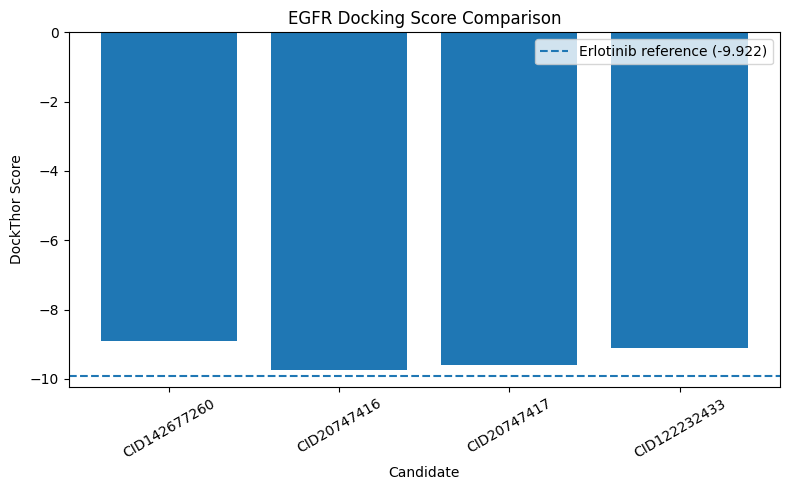

In [532]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    final_results["CID"],
    final_results["DockThor_Score"]
)

plt.axhline(
    y=-9.922,
    linestyle="--",
    label="Erlotinib reference (-9.922)"
)

plt.ylabel("DockThor Score")
plt.xlabel("Candidate")
plt.title("EGFR Docking Score Comparison")
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()

plt.show()

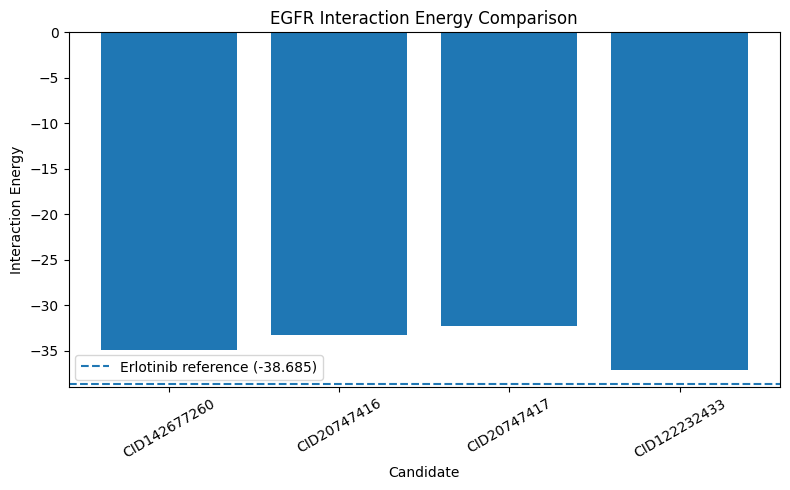

In [533]:
plt.figure(figsize=(8,5))

plt.bar(
    final_results["CID"],
    final_results["Interaction_Energy"]
)

plt.axhline(
    y=-38.685,
    linestyle="--",
    label="Erlotinib reference (-38.685)"
)

plt.ylabel("Interaction Energy")
plt.xlabel("Candidate")
plt.title("EGFR Interaction Energy Comparison")
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()

plt.show()

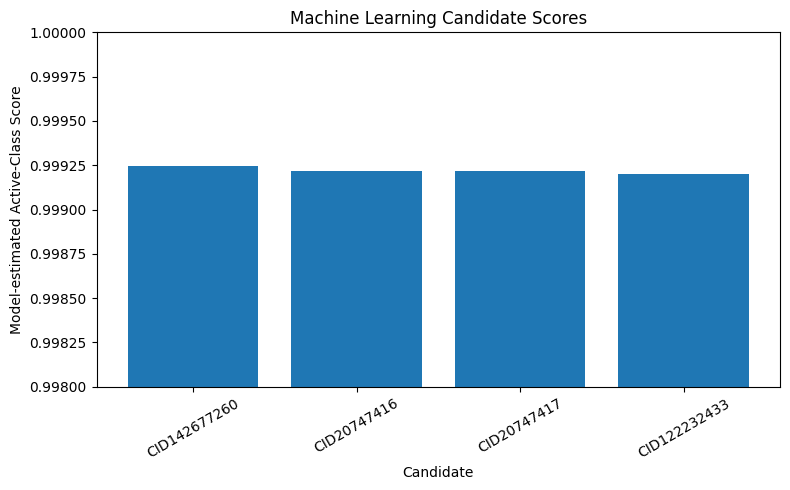

In [534]:
plt.figure(figsize=(8,5))

plt.bar(
    final_results["CID"],
    final_results["ML_Active_Score"]
)

plt.ylabel("Model-estimated Active-Class Score")
plt.xlabel("Candidate")
plt.title("Machine Learning Candidate Scores")

plt.ylim(0.998, 1.000)

plt.xticks(rotation=30)
plt.tight_layout()

plt.show()

In [535]:
summary_cols = [
    "CID",
    "ML_Active_Score",
    "Max_Training_Tanimoto",
    "DockThor_Score",
    "Interaction_Energy",
    "MW",
    "logP",
    "TPSA",
    "HBD",
    "HBA",
    "HIA",
    "BBB",
    "Ames",
    "QED",
    "Lipinski",
    "Synthetic_Accessibility"
]

final_summary = final_results[
    [c for c in summary_cols if c in final_results.columns]
].copy()

final_summary.round(3)

,CID,ML_Active_Score,Max_Training_Tanimoto,DockThor_Score,Interaction_Energy,MW,logP,TPSA,HBD,HBA,HIA,BBB,Ames,QED,Lipinski,Synthetic_Accessibility
0,CID142677260,0.999,0.351,-8.912,-34.893,391.11,3.811,76.50,2,6,0.011,0.001,0.304,0.702,0,3
1,CID20747416,0.999,0.559,-9.739,-33.328,385.04,4.471,56.27,1,5,0.006,0.006,0.469,0.708,0,2
2,CID20747417,0.999,0.509,-9.594,-32.274,321.15,4.152,56.27,1,5,0.002,0.000,0.594,0.782,0,2
3,CID122232433,0.999,0.448,-9.112,-37.118,367.16,2.087,103.55,4,8,0.003,0.000,0.707,0.608,0,3


In [536]:
reference_row = pd.DataFrame({
    "CID": ["Erlotinib reference"],
    "ML_Active_Score": [np.nan],
    "Max_Training_Tanimoto": [np.nan],
    "DockThor_Score": [-9.922],
    "Interaction_Energy": [-38.685]
})

comparison_with_reference = pd.concat(
    [reference_row, final_results],
    ignore_index=True,
    sort=False
)

comparison_with_reference[
    [
        "CID",
        "ML_Active_Score",
        "Max_Training_Tanimoto",
        "DockThor_Score",
        "Interaction_Energy"
    ]
].round(3)

,CID,ML_Active_Score,Max_Training_Tanimoto,DockThor_Score,Interaction_Energy
0,Erlotinib reference,NaN,NaN,-9.922,-38.685
1,CID142677260,0.999,0.351,-8.912,-34.893
2,CID20747416,0.999,0.559,-9.739,-33.328
3,CID20747417,0.999,0.509,-9.594,-32.274
4,CID122232433,0.999,0.448,-9.112,-37.118


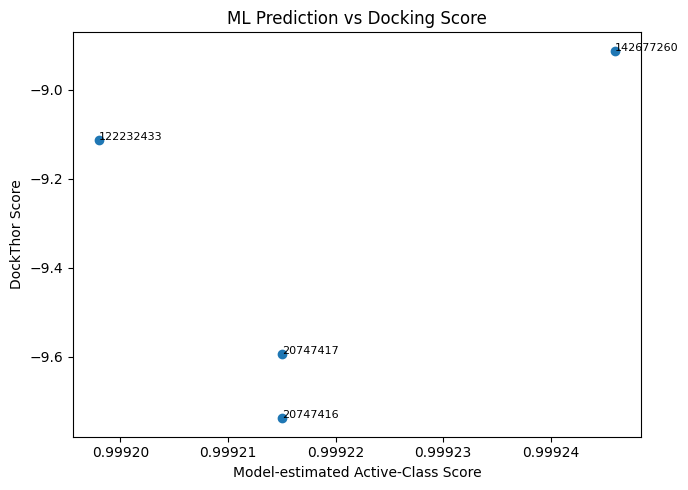

In [537]:
plt.figure(figsize=(7,5))

plt.scatter(
    final_results["ML_Active_Score"],
    final_results["DockThor_Score"]
)

for _, row in final_results.iterrows():
    plt.annotate(
        row["CID"].replace("CID", ""),
        (
            row["ML_Active_Score"],
            row["DockThor_Score"]
        ),
        fontsize=8
    )

plt.xlabel("Model-estimated Active-Class Score")
plt.ylabel("DockThor Score")
plt.title("ML Prediction vs Docking Score")
plt.tight_layout()

plt.show()

In [538]:
final_summary.to_csv(
    "EGFR_Final_Summary.csv",
    index=False
)

print("Saved: EGFR_Final_Summary.csv")

Saved: EGFR_Final_Summary.csv


In [539]:
from google.colab import files

files.download("EGFR_Final_Summary.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Limitations

- IC50 measurements were obtained from different ChEMBL assays, and experimental conditions may vary between studies.
- Only exact IC50 values reported in nM were retained.
- Duplicate measurements for identical compounds were summarized using the median IC50.
- Activity thresholds used in this project were project-defined and should not be interpreted as universal pharmacological cutoffs.
- Random train/test splitting produced very high performance and may have benefited from structural similarity between training and test compounds.
- Scaffold-based splitting produced lower ROC-AUC, PR-AUC and recall, indicating reduced performance on structurally distinct chemical series.
- The PubChem screening library was generated using similarity to erlotinib and is therefore biased toward erlotinib-like chemical space.
- Machine-learning active-class scores should not be interpreted as experimentally measured probabilities of EGFR inhibition.
- Molecular docking scores are approximate computational scoring values and are not experimental binding affinities.
- The erlotinib run was used as a reference docking comparison; a formal crystal-pose RMSD redocking validation was not completed.
- ADMETlab results are computational predictions and require experimental confirmation.
- The final compounds are computationally prioritized candidates only and have not been experimentally validated for EGFR inhibition, safety, or therapeutic efficacy.

## Overall Workflow

ChEMBL EGFR bioactivity data  
→ Data cleaning and pIC50 transformation  
→ Activity classification  
→ Molecular descriptors and Morgan fingerprints  
→ Logistic Regression, Random Forest and XGBoost  
→ Random split evaluation  
→ Scaffold-based validation  
→ PubChem external screening  
→ Candidate ranking using ML score and Tanimoto similarity  
→ Molecular docking against EGFR  
→ Protein-ligand interaction analysis  
→ ADMET prediction  
→ Final computational candidate prioritization

## Conclusion

This project developed an end-to-end computational workflow for the prioritization of potential EGFR-active compounds using public bioactivity data, cheminformatics, machine learning, molecular docking, and in-silico ADMET prediction.

ChEMBL EGFR IC50 data were curated, converted to pIC50 values and classified into active and inactive compounds. Molecular descriptors and Morgan fingerprints were generated, and Logistic Regression, Random Forest and XGBoost classifiers were evaluated.

The random train/test split produced very high predictive performance. However, scaffold-based validation showed reduced ROC-AUC, PR-AUC and recall, demonstrating the importance of evaluating structural generalization rather than relying only on random splitting.

The trained XGBoost model was then used to screen a PubChem library of erlotinib-similar compounds after removing exact overlaps with the training dataset. Candidates were prioritized using model-estimated active-class scores together with similarity-to-training measurements.

Selected compounds were further evaluated by molecular docking against EGFR, using erlotinib as a reference compound, followed by protein-ligand interaction analysis and ADMET prediction.

These results should be interpreted as computational prioritization rather than experimental validation. Further biochemical, cellular, pharmacokinetic and toxicity studies would be required before any therapeutic conclusions could be made.